# 實驗分組

- 測站劃分:
    - treatment(都市交通要地):
        - 交通空氣品質監測站:
            - 永和(新北)
            - 中壢(桃園)
            - 鳳山、復興(高雄)

    - control 1 (非都市區域):
        - 背景空氣品質監測站:三義、橋頭、富貴
    
    - control 2 (都市一般地區):
        - 一般空氣品質監測站:
            - 板橋、菜寮、士林(新北)
            - 平鎮(桃園)
            - 左營、前金、小港(高雄)


- 時間劃分
    - 以2021/05/19全國COVID三級警戒為政策影響點
        - 前2年(2019/05/19~2021/5/19)為training data
        - 後6周(2021/5/19~2021/6/30)為inference data

- 預測目標
    - treatment的 NO2 level(交通排放指標) 在Covid 3級警戒下是否影響
    - 以 no2(只有control組), pm2.5_avg, pm10_avg, windspeed, wind_x, wind_y, weekday, is_weekend, month 當輔助指標

- 實驗分組
    1. treatment noly
    2. treatment + c1
    3. treatment + c2
    4. treatment + c1 + c2


In [1]:
import os
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from io import StringIO

from api import api_key

In [3]:
api_url = "https://data.moenv.gov.tw/api/v2"
dataset = "AQX_P_488"

#參數格式:{api_url}/{dataset}?api_key={api_key}...

base_url = f"{api_url}/{dataset}?api_key={api_key}&format=CSV"

date_filter = "|datacreationdate,GR,2019-05-19|datacreationdate,LT,2021-06-30"
site_filter = "&filters=sitename,EQ,鳳山,中壢,永和,復興,觀音,三義,橋頭,富貴,恆春,陽明,板橋,新莊,菜寮,士林,桃園,大園,平鎮,左營,前金,小港"

query_url = base_url + site_filter + date_filter

offset = 0
page_size = 1000

data_pages = []

while True:
    paged_url = query_url + f"&offset={offset}"

    response = requests.get(paged_url, timeout=30)
    response.raise_for_status()

    page_df = pd.read_csv(StringIO(response.text))

    if page_df.empty:
        break

    data_pages.append(page_df)
    print(f"offset={offset}, rows={len(page_df)}")

    if len(page_df) < page_size:
        break

    offset += page_size

air_quality_df = pd.concat(data_pages, ignore_index=True)

print(air_quality_df.shape)
print(air_quality_df.head())

offset=0, rows=1000
offset=1000, rows=1000
offset=2000, rows=1000
offset=3000, rows=1000
offset=4000, rows=1000
offset=5000, rows=1000
offset=6000, rows=1000
offset=7000, rows=1000
offset=8000, rows=1000
offset=9000, rows=1000
offset=10000, rows=1000
offset=11000, rows=1000
offset=12000, rows=1000
offset=13000, rows=1000
offset=14000, rows=1000
offset=15000, rows=1000
offset=16000, rows=1000
offset=17000, rows=1000
offset=18000, rows=1000
offset=19000, rows=1000
offset=20000, rows=1000
offset=21000, rows=1000
offset=22000, rows=1000
offset=23000, rows=1000
offset=24000, rows=1000
offset=25000, rows=1000
offset=26000, rows=1000
offset=27000, rows=1000
offset=28000, rows=1000
offset=29000, rows=1000
offset=30000, rows=1000
offset=31000, rows=1000
offset=32000, rows=1000
offset=33000, rows=1000
offset=34000, rows=1000
offset=35000, rows=1000
offset=36000, rows=1000
offset=37000, rows=1000
offset=38000, rows=1000
offset=39000, rows=1000
offset=40000, rows=1000
offset=41000, rows=1000
offse

In [4]:
output_dir = "./data/"
os.makedirs(output_dir,exist_ok=True)
air_quality_df.to_csv(os.path.join(output_dir, "raw.csv"), index=False)

# 前處理
- 風向角度轉形
- 日期完整性
- dupilcate check
- 異常值 check
- 聚合層級 (先做每站每日平均,再做跨站彙整)
- missing data check
- imputation

- 風向角度轉形
    - 359度和1度其實差不多，但平均會變成180度
    - 轉成用cos, sin紀錄

In [5]:
df = air_quality_df.copy()
df["datacreationdate"] = pd.to_datetime(df["datacreationdate"], errors="coerce")

df["windspeed"] = pd.to_numeric(df["windspeed"], errors="coerce")
df["winddirec"] = pd.to_numeric(df["winddirec"], errors="coerce")
theta = np.deg2rad(df["winddirec"])
df["wind_x"] = np.cos(theta)
df["wind_y"] = np.sin(theta)

- dupilcate check
    - 確認日期和站點資料沒有重複，以避免算平均時權重失調

In [6]:
dup_n = df.duplicated(subset=["sitename", "datacreationdate"]).sum()
print("Duplicate rows:", dup_n)

Duplicate rows: 0


- 異常值check
    - 確認無負數、極端值

In [7]:
cols = ["no2", "windspeed", "winddirec"]
print(df[cols].describe())

                 no2      windspeed      winddirec
count  334309.000000  331984.000000  331861.000000
mean       12.848695       2.503026     156.468345
std         9.502588       1.823080     111.026653
min        -0.500000       0.000000       0.000000
25%         5.900000       1.200000      59.000000
50%        11.000000       2.000000     130.000000
75%        18.000000       3.200000     258.000000
max        87.700000      18.000000     990.000000


- missing data check
    - daily mean是先site內平均，再site間平均，避免不同site全重不同
    - missing rate 是算原始缺少比例
    - 將資料缺失較為嚴重的站點剔除

- 加入時間尺度
    - 包含星期幾，是否周末，國定假日
    - 月份

In [8]:
cols = ["no2","pm2.5_avg","pm10_avg","windspeed","winddirec"]
missing_time = df["datacreationdate"].isna().sum()
print(f"Time missing: {missing_time}")

missing = {}
rate = {}

for col in cols:
    missing[col] = df[col].isna().sum()
    rate[col] = missing[col]/len(air_quality_df)
    print(f"{col} missing: {missing[col]}, missimg rate: {rate[col]:.4f}")



site_missing = df.groupby("sitename")[cols].apply(lambda x: x.isna().sum())
print(f"\n{site_missing}")

Time missing: 0
no2 missing: 11990, missimg rate: 0.0346
pm2.5_avg missing: 6900, missimg rate: 0.0199
pm10_avg missing: 8517, missimg rate: 0.0246
windspeed missing: 14315, missimg rate: 0.0413
winddirec missing: 14438, missimg rate: 0.0417

           no2  pm2.5_avg  pm10_avg  windspeed  winddirec
sitename                                                 
三義         378        305       355         59         59
中壢         512        300       556         92         92
前金         386        212       397        130        130
士林        1018        413       543        186        185
大園         829        344       377        219        179
小港         479        299       382         66         66
左營         416        286       269         94         94
平鎮         538        392       208        125        125
復興         732        282       384         74         74
恆春         908        563       531        449        406
新莊         735        452       685        199        198
板橋 

In [ ]:
treatment_sites = ["鳳山", "中壢", "永和", "復興"]
c1_sites = ["三義", "橋頭", "富貴"]
c2_sites = ["板橋", "菜寮", "士林", "平鎮", "左營", "前金", "小港"]
all_sites = treatment_sites + c1_sites + c2_sites

df = df[df["sitename"].isin(all_sites)].copy()

In [12]:

df["period"] = df["datacreationdate"].apply(
    lambda x: "pre" if x < pd.Timestamp("2021-05-19") else "post"
)
print(
    df.groupby("period")[cols]
    .apply(lambda x: x.isna().sum())
)

missing_rate_by_period = df.groupby("period")[cols].apply(
    lambda x: x.isna().mean()
)

print(f"\n{(missing_rate_by_period * 100).round(2)}")

         no2  pm2.5_avg  pm10_avg  windspeed  winddirec
period                                                 
post     385       1192        65         21         21
pre     6403       2692      4601       1313       1532

         no2  pm2.5_avg  pm10_avg  windspeed  winddirec
period                                                 
post    2.94       9.10      0.50       0.16       0.16
pre     2.88       1.21      2.07       0.59       0.69


In [34]:
def draw_daily_mean(df, cols, groups, mr_dict):
    fig, ax = plt.subplots(len(cols)*2, 1, figsize=(len(cols)*1.5,len(cols)*3.5), sharex=True, gridspec_kw={"height_ratios": [3,1]*len(cols)})
    for i, col in enumerate(cols):
        j = i*2
        for g in groups:
            s = df[df["group"] == g][col]
            ax[j].plot(s.index, s.values, label=g)
            s = mr_dict[col].loc[g]
            ax[j+1].bar(s.index, s.values, alpha=0.5, label=g)

        ax[j].set_title(f"Daily Mean {col}")
        ax[j].axvline(pd.to_datetime("2021-05-19"), linestyle="--")
        ax[j].legend()

        ax[j+1].set_title(f"Daily {cols[i]} Missing Rate")
        ax[j+1].axvline(pd.to_datetime("2021-05-19"), linestyle="--")
        ax[j+1].legend()

    ax[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=4))
    ax[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

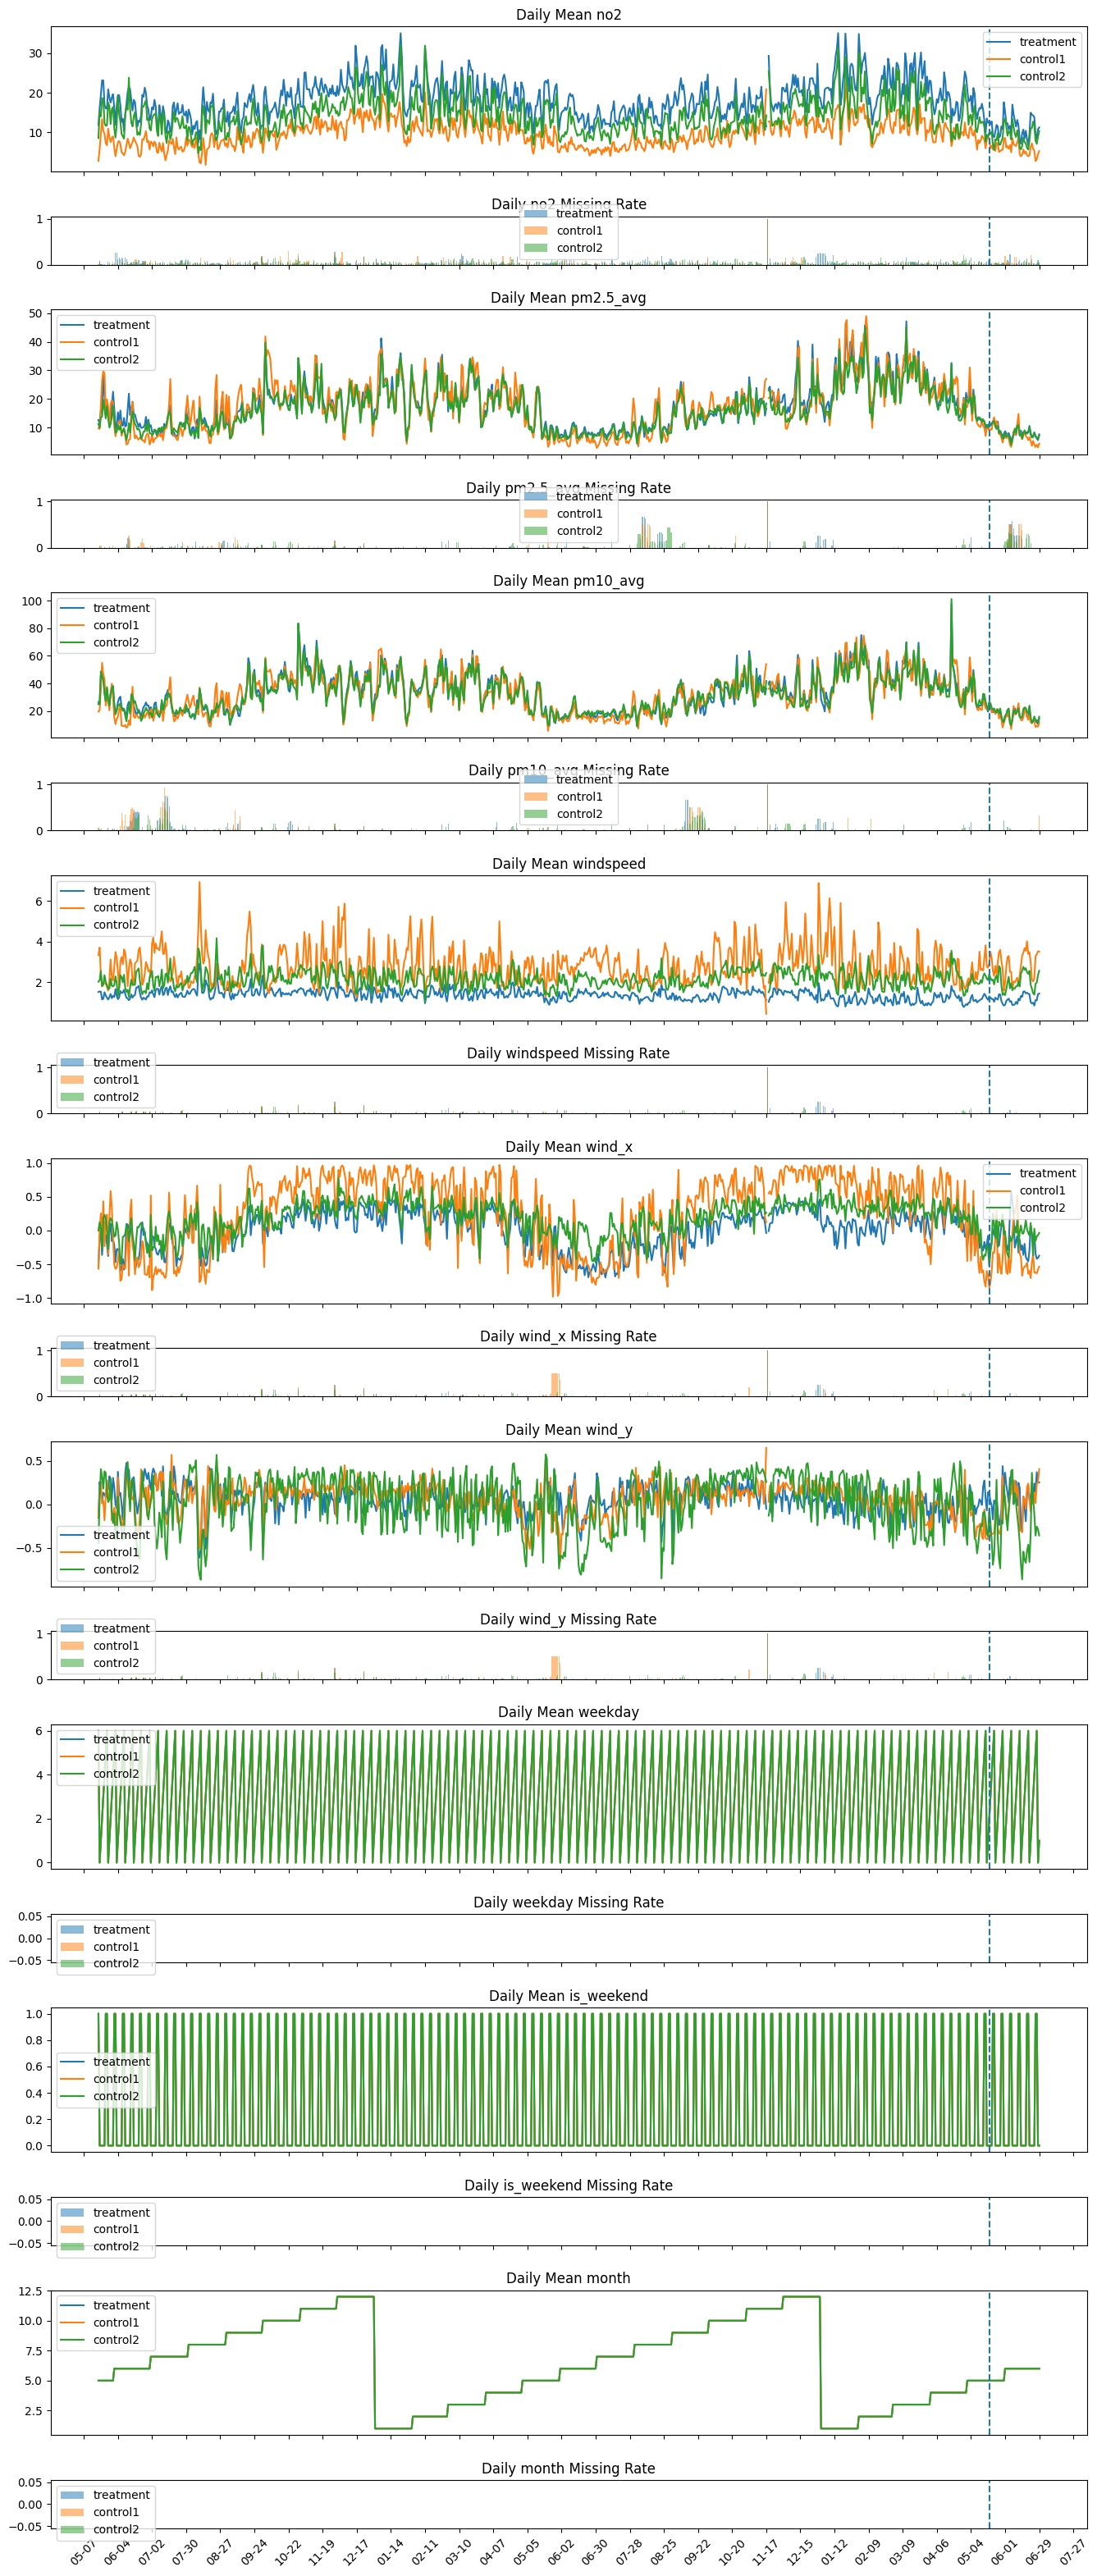

In [35]:
#分組設定
value_cols = ["no2", "pm2.5_avg", "pm10_avg", "windspeed", "wind_x", "wind_y"]
calendar_cols = ["weekday", "is_weekend", "month"]
all_cols = value_cols + calendar_cols

groups = ["treatment", "control1", "control2"]
site_to_group = {s: "treatment" for s in treatment_sites}
site_to_group.update({s: "control1" for s in c1_sites})
site_to_group.update({s: "control2" for s in c2_sites})


plot_df = df.sort_values("datacreationdate")
plot_df["date"] = plot_df["datacreationdate"].dt.floor("D")
plot_df["group"] = plot_df["sitename"].map(site_to_group)
plot_df = plot_df.dropna(subset=["group"])

full_dates = pd.date_range(
    start=plot_df["date"].min(),
    end=plot_df["date"].max(),
    freq="D"
)

full_index = pd.MultiIndex.from_product(
    [groups, full_dates],
    names=["group", "date"]
)


site_daily_mean = plot_df.groupby(["group","sitename","date"])[value_cols].mean()
daily = site_daily_mean.groupby(["group","date"]).mean().reindex(full_index).reset_index()
daily = daily.set_index("date").sort_index()

daily["weekday"] = daily.index.weekday
daily["is_weekend"] = daily["weekday"].isin([5, 6]).astype(int)
daily["month"] = daily.index.month

daily_total_count = plot_df.groupby(["group", "date"]).size().reindex(full_index, fill_value=0)

mr_dict = {}
for col in value_cols:
    cnt = plot_df.groupby(["group", "date"])[col].count().reindex(full_index, fill_value=0)

    mr = 1 - (cnt / daily_total_count.replace(0, np.nan))
    mr[daily_total_count == 0] = 1.0
    mr_dict[col] = mr

for col in calendar_cols:
    mr_dict[col] = pd.Series(0.0, index=full_index)

num_cols = len(all_cols)

draw_daily_mean(daily, all_cols, groups, mr_dict)

In [37]:
daily.to_csv(os.path.join(output_dir, "daily.csv"))

- Imputation
    - 時間序列線性補值

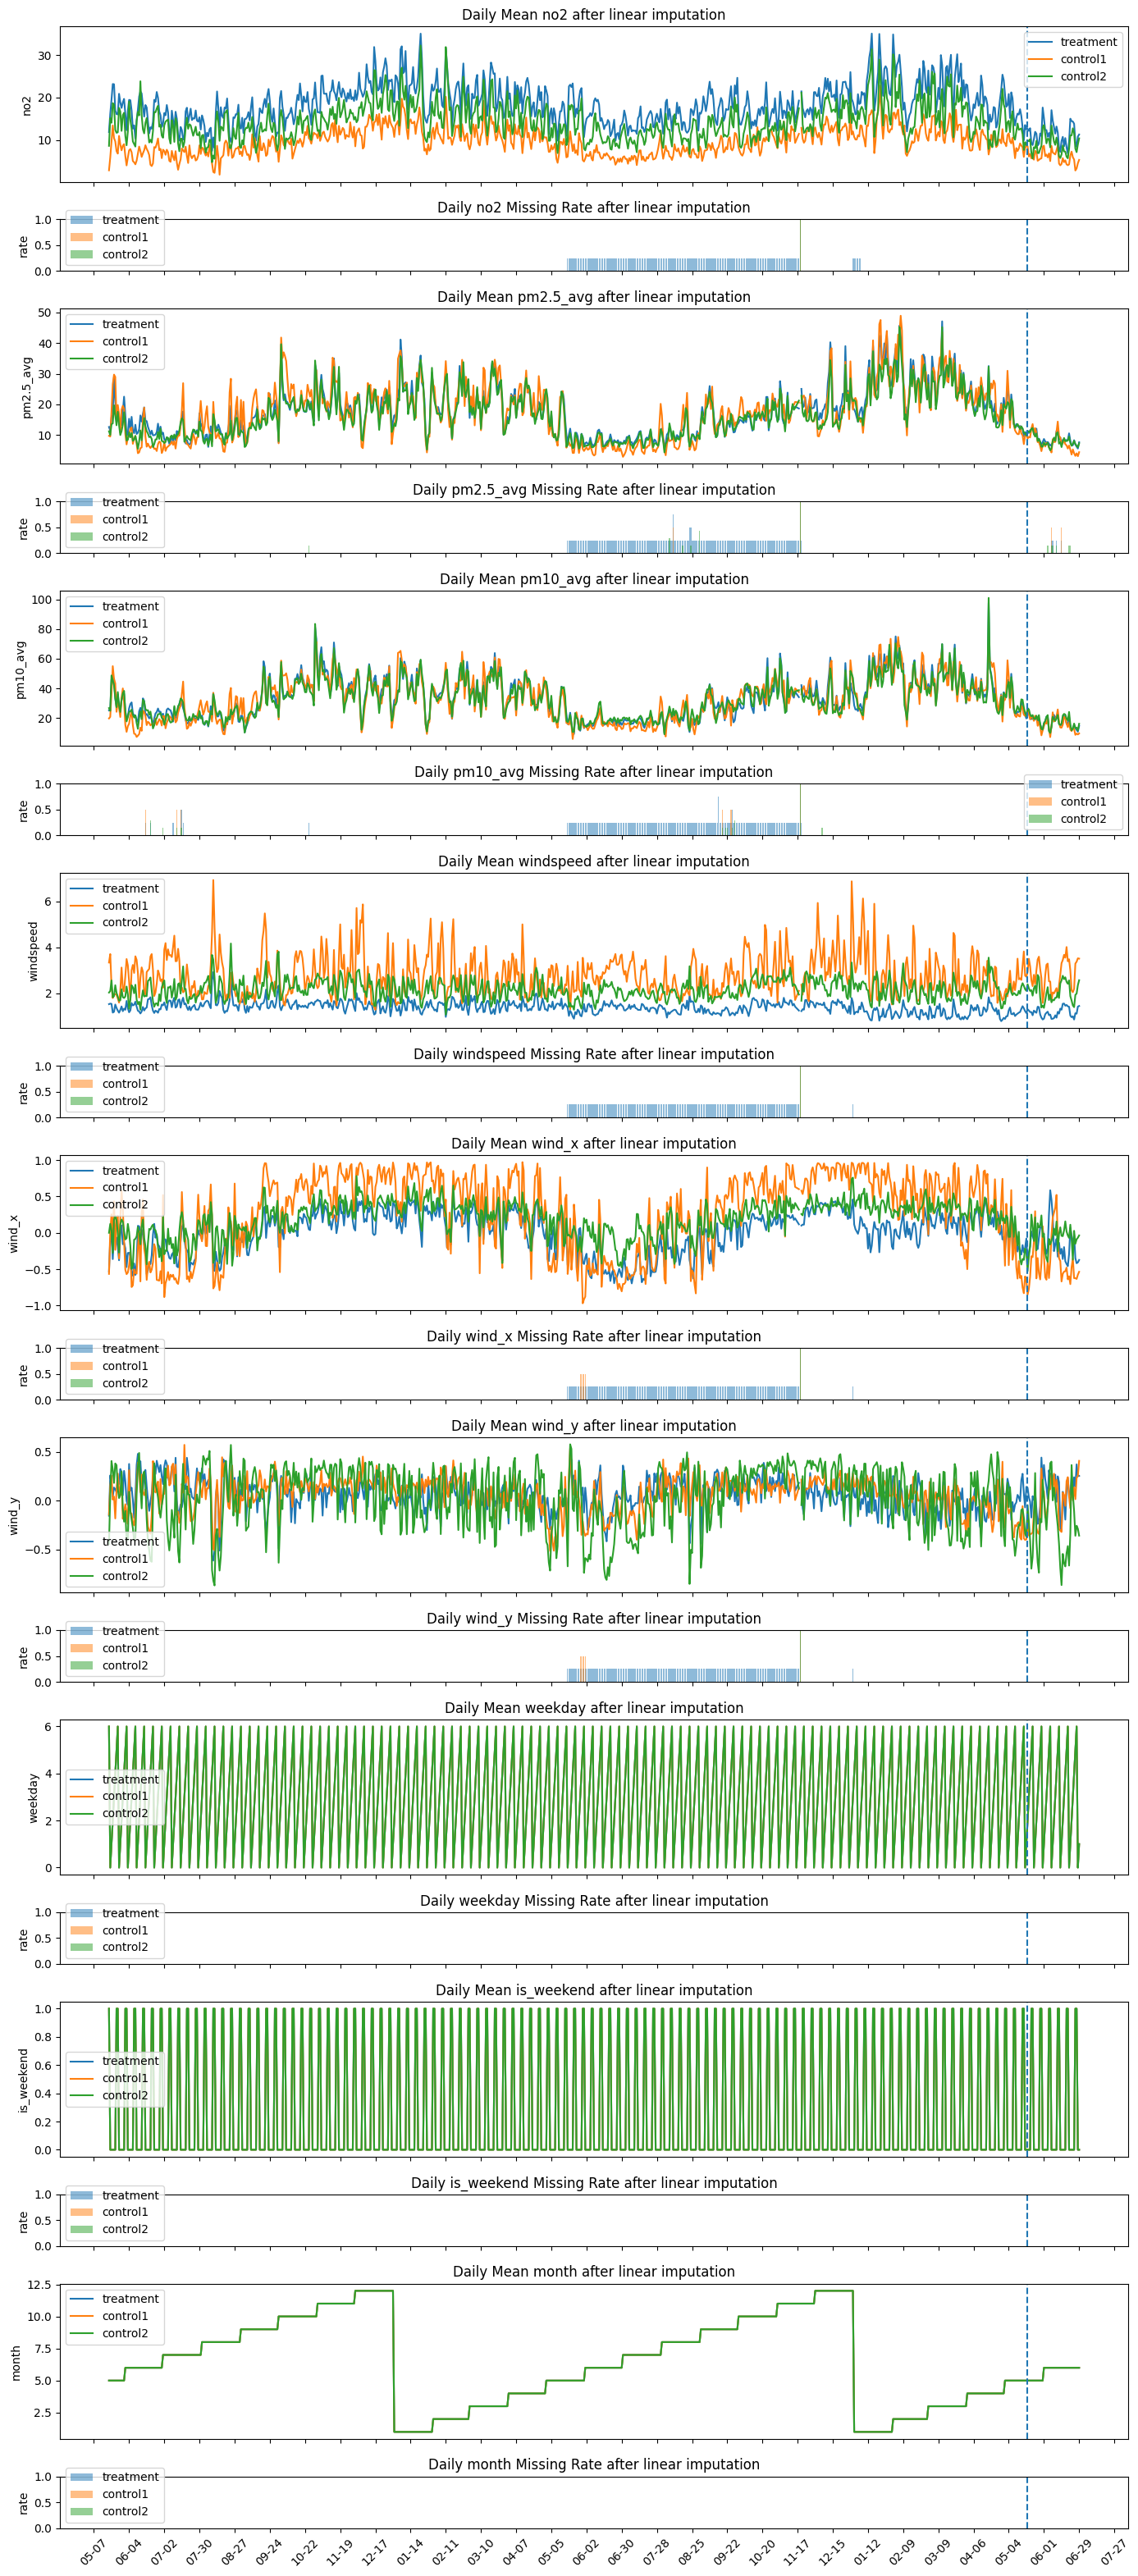

In [38]:
min_hours = 12


# ========= 1) 基本清理 =========
plot_df = df.copy()
plot_df["datacreationdate"] = pd.to_datetime(plot_df["datacreationdate"], errors="coerce")
plot_df = plot_df.dropna(subset=["datacreationdate"]).copy()
plot_df = plot_df.sort_values(["sitename", "datacreationdate"]).copy()

plot_df["group"] = plot_df["sitename"].map(site_to_group)
plot_df = plot_df.dropna(subset=["group"]).copy()

plot_df["date"] = plot_df["datacreationdate"].dt.floor("D")


# ========= 2) 每站每天 daily mean / daily count =========
site_daily_mean = (
    plot_df.groupby(["group", "sitename", "date"])[value_cols]
    .mean()
)

site_daily_count = (
    plot_df.groupby(["group", "sitename", "date"])[value_cols]
    .count()
)


# ========= 3) Daily QC：至少 min_hours 小時有效才保留 =========
site_daily_qc = site_daily_mean.copy()

for col in value_cols:
    site_daily_qc[col] = site_daily_qc[col].where(site_daily_count[col] >= min_hours)

site_daily_qc = site_daily_qc.reset_index()


# ========= 4) 每站補齊 daily 日期，並做 daily interpolation =========
out = []

for (group, site), g in site_daily_qc.groupby(["group", "sitename"]):
    g = g.sort_values("date").set_index("date")

    full_dates_site = pd.date_range(
        start=g.index.min(),
        end=g.index.max(),
        freq="D"
    )

    g = g.reindex(full_dates_site)
    g.index.name = "date"

    g["group"] = group
    g["sitename"] = site

    for col in value_cols:
        g[f"{col}_imp_l"] = g[col].interpolate(
            method="time",
            limit=3
        )

    out.append(g.reset_index())

plot_imp = pd.concat(out, ignore_index=True)


# ========= 5) 建全域 group × date index =========
full_dates_global = pd.date_range(
    start=plot_imp["date"].min(),
    end=plot_imp["date"].max(),
    freq="D"
)

full_index = pd.MultiIndex.from_product(
    [groups, full_dates_global],
    names=["group", "date"]
)


# ========= 6) 補值後 daily mean（每個 group 各自跨站平均） =========
daily = (
    plot_imp.groupby(["group", "date"])[[f"{col}_imp_l" for col in value_cols]]
    .mean()
    .reindex(full_index)
    .reset_index()
)

daily = daily.set_index("date").sort_index()


# ========= 7) calendar 欄位由日期直接生成 =========
daily["weekday"] = daily.index.weekday
daily["is_weekend"] = daily["weekday"].isin([5, 6]).astype(int)
daily["month"] = daily.index.month


# ========= 8) 補值後 missing rate（每個 group 各自 across 測站） =========
mr_after = {}

for col in value_cols:
    mr_after[col] = (
        plot_imp.groupby(["group", "date"])[f"{col}_imp_l"]
        .apply(lambda x: x.isna().mean())
        .reindex(full_index, fill_value=1.0)
    )

# calendar 欄位視為不缺
for col in calendar_cols:
    mr_after[col] = pd.Series(0.0, index=full_index)

# plot
daily_plot = daily.reset_index().copy()

fig, ax = plt.subplots(
    len(all_cols) * 2,
    1,
    figsize=(14, len(all_cols) * 3.5),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1] * len(all_cols)}
)

for i, col in enumerate(all_cols):
    j = i * 2

    # ===== 上面：daily mean =====
    for g in groups:
        gdf = daily_plot[daily_plot["group"] == g]

        if col in value_cols:
            y = gdf[f"{col}_imp_l"]
        else:
            y = gdf[col]

        ax[j].plot(gdf["date"], y, label=g)

    ax[j].set_title(f"Daily Mean {col} after linear imputation")
    ax[j].axvline(pd.to_datetime("2021-05-19"), linestyle="--")
    ax[j].set_ylabel(col)
    ax[j].legend()

    # ===== 下面：missing rate =====
    for g in groups:
        s = mr_after[col].xs(g, level="group")
        ax[j+1].bar(s.index, s.values, alpha=0.5, label=g)

    ax[j+1].set_title(f"Daily {col} Missing Rate after linear imputation")
    ax[j+1].axvline(pd.to_datetime("2021-05-19"), linestyle="--")
    ax[j+1].set_ylabel("rate")
    ax[j+1].set_ylim(0, 1)
    ax[j+1].legend()

ax[-1].xaxis.set_major_locator(mdates.WeekdayLocator(interval=4))
ax[-1].xaxis.set_major_formatter(mdates.DateFormatter("%m-%d"))

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
daily.to_csv(os.path.join(output_dir, "daily_imp2.csv"))

# SSSD格式處理

- input shape: `(N, L, C)`
  - N = windows 數量
  - L = 168 小時（7 天）
  - C = 特徵數（依組別而定）

- window
  - size: 168 h，stride: 24 h
  - 以 **treatment 站** 為主軸切 window；control 站取跨站平均後附加為額外欄位

- 四個實驗組別

| 組別 | 內容 | C |
|------|------|---|
| g1 | treatment only | 6 |
| g2 | treatment + c1 avg | 12 |
| g3 | treatment + c2 avg | 12 |
| g4 | treatment + c1 avg + c2 avg | 18 |

- 欄位順序（每 6 欄一組）：`no2, pm2.5_avg, pm10_avg, windspeed, wind_x, wind_y`
- mask：1 = 原始有觀測值，0 = 缺值（在 SSSD inference 時再決定要遮哪些）

In [8]:
# ========= Load & basic prep =========
raw_path = "./data/raw.csv"
df_raw = pd.read_csv(raw_path, low_memory=False)
df_raw["datacreationdate"] = pd.to_datetime(df_raw["datacreationdate"], errors="coerce")
df_raw = df_raw.dropna(subset=["datacreationdate", "sitename"]).copy()
df_raw = df_raw.sort_values(["sitename", "datacreationdate"])

for col in ["no2", "pm2.5_avg", "pm10_avg", "windspeed", "winddirec"]:
    df_raw[col] = pd.to_numeric(df_raw[col], errors="coerce")

theta = np.deg2rad(df_raw["winddirec"])
df_raw["wind_x"] = df_raw["windspeed"] * np.sin(theta)
df_raw["wind_y"] = df_raw["windspeed"] * np.cos(theta)

# ========= Site groups =========
treatment_sites = ["鳳山", "中壢", "永和", "復興"]
c1_sites = ["三義", "橋頭", "富貴"]
c2_sites = ["板橋", "菜寮", "士林", "平鎮", "左營", "前金", "小港"]

available = set(df_raw["sitename"].unique())
c1_sites = [s for s in c1_sites if s in available]
c2_sites = [s for s in c2_sites if s in available]
all_sites = treatment_sites + c1_sites + c2_sites

df_sssd = df_raw[df_raw["sitename"].isin(all_sites)].copy()

features = ["no2", "pm2.5_avg", "pm10_avg", "windspeed", "wind_x", "wind_y"]
seq_len = 168
stride = 24

# 預建站點索引，避免重複掃描
site_dfs = {
    s: df_sssd[df_sssd["sitename"] == s].set_index("datacreationdate").sort_index()
    for s in all_sites
}

# ========= Helper: 單站 → 補值後 array + observed mask =========
def site_series(site, idx):
    g = site_dfs[site].reindex(idx)
    x_raw = g[features].to_numpy(dtype=np.float32)
    mask = (~np.isnan(x_raw)).astype(np.float32)
    xdf = pd.DataFrame(x_raw, index=idx, columns=features)
    xdf = xdf.interpolate(method="time", limit_direction="both").ffill().bfill().fillna(0.0)
    return xdf.to_numpy(dtype=np.float32), mask

# ========= Helper: 多站平均 → ctrl array + ctrl mask =========
def ctrl_mean(sites, idx):
    xs, ms = [], []
    for s in sites:
        if s not in site_dfs:
            continue
        x, m = site_series(s, idx)
        xs.append(x)
        ms.append(m)
    if not xs:
        empty = np.zeros((len(idx), len(features)), dtype=np.float32)
        return empty, empty
    ctrl_x = np.mean(xs, axis=0).astype(np.float32)
    ctrl_m = (np.mean(ms, axis=0) > 0).astype(np.float32)
    return ctrl_x, ctrl_m

# ========= Build one group =========
def build_group(ctrl_groups):
    """ctrl_groups: list of site lists, e.g. [c1_sites] or [c1_sites, c2_sites]"""
    windows, masks, meta = [], [], []
    for site in treatment_sites:
        if site not in site_dfs or site_dfs[site].empty:
            continue
        idx = pd.date_range(site_dfs[site].index.min(), site_dfs[site].index.max(), freq="h")

        x_t, m_t = site_series(site, idx)

        ctrl_xs, ctrl_ms = [], []
        for ctrl_sites in ctrl_groups:
            cx, cm = ctrl_mean(ctrl_sites, idx)
            ctrl_xs.append(cx)
            ctrl_ms.append(cm)

        X_full = np.concatenate([x_t] + ctrl_xs, axis=1)
        M_full = np.concatenate([m_t] + ctrl_ms, axis=1)

        T = len(idx)
        for start in range(0, T - seq_len + 1, stride):
            end = start + seq_len
            windows.append(X_full[start:end])
            masks.append(M_full[start:end])
            meta.append({"site": site, "start_time": idx[start], "end_time": idx[end - 1]})

    X = np.stack(windows).astype(np.float32)
    M = np.stack(masks).astype(np.float32)
    return X, M, pd.DataFrame(meta)

# ========= 四組 =========
group_configs = {
    "g1_treatment":   [],
    "g2_treat_c1":    [c1_sites],
    "g3_treat_c2":    [c2_sites],
    "g4_treat_c1_c2": [c1_sites, c2_sites],
}

out_dir = "./data/sssd/"
os.makedirs(out_dir, exist_ok=True)

for name, ctrl_groups in group_configs.items():
    X, M, meta = build_group(ctrl_groups)
    n_ctrl = len(ctrl_groups)
    C = 6 * (1 + n_ctrl)
    print(f"{name}: X={X.shape}  C={C}  obs_ratio={M.mean():.4f}  NaN={np.isnan(X).sum()}")
    np.save(f"{out_dir}/{name}_X.npy", X)
    np.save(f"{out_dir}/{name}_M.npy", M)
    meta.to_csv(f"{out_dir}/{name}_meta.csv", index=False)

print(f"\nSaved to {out_dir}")

g1_treatment: X=(3068, 168, 6)  C=6  obs_ratio=0.9198  NaN=0
g2_treat_c1: X=(3068, 168, 12)  C=12  obs_ratio=0.9565  NaN=0
g3_treat_c2: X=(3068, 168, 12)  C=12  obs_ratio=0.9572  NaN=0
g4_treat_c1_c2: X=(3068, 168, 18)  C=18  obs_ratio=0.9692  NaN=0

Saved to ./data/sssd/
